# SET modal decomposition

SET stores the original STFT coefficient on the instantaneous-frequency
ridge, so a real-valued mode is the time series of those coefficients.
For a $K$-component mixture the MATLAB companion (`brevridge_mult` +
`real(Te(Cs,t))`) walks $K$ ridges of $|T_e|$, clearing a frequency
window after each one. PySDKit wraps that as `SET.fit_transform`:

$
s_k(t)=\mathrm{Re}\,T_e\bigl(t,\,\hat\varphi'_k(t)\bigr),\qquad
r(t)=x(t)-\sum_{k=1}^{K}s_k(t).
$

The last row of the IMF array is the residual $r$, matching the rest
of PySDKit.

This notebook is the multi-component numerical example of Yu et al.
(IEEE TIE 2017, Figures 12 / 15–17; MATLAB `Example_2.m`).

**Reference**

> G. Yu, M. Yu, C. Xu, *Synchroextracting Transform*,
> IEEE Transactions on Industrial Electronics 64(10):8042–8054, 2017.


## 1. Imports


In [1]:
import sys
from pathlib import Path

ROOT = Path.cwd().resolve()
if not (ROOT / "pysdkit").is_dir():
    for parent in ROOT.parents:
        if (parent / "pysdkit").is_dir():
            ROOT = parent
            break
if str(ROOT) not in sys.path and (ROOT / "pysdkit").is_dir():
    sys.path.insert(0, str(ROOT))

import numpy as np
import matplotlib.pyplot as plt

from pysdkit import SET
from pysdkit.data import load_set_batdata2, load_set_vibdata

print("pysdkit from:", Path(__import__("pysdkit").__file__).resolve())
print(SET())

pysdkit from: C:\Users\whenx\Desktop\PySDKit\pysdkit\__init__.py
Synchroextracting Transform (SET)


## 2. Three AM–FM tones (`Example_2.m`)

$$
\begin{aligned}
s_1(t)&=\sin\bigl(2\pi(10t+2\arctan((2t-2)^2))\bigr),\\
s_2(t)&=\sin\bigl(2\pi(32t+10\sin t)\bigr),\\
s_3(t)&=\sin\bigl(2\pi(44t+10\sin t)\bigr),
\end{aligned}
$$

sampled at $F_s=120$ Hz on $[0,4)$. Window length 55 samples.


Te (240, 480)   IMFs (4, 480)
relative residual 0.08488761954876863


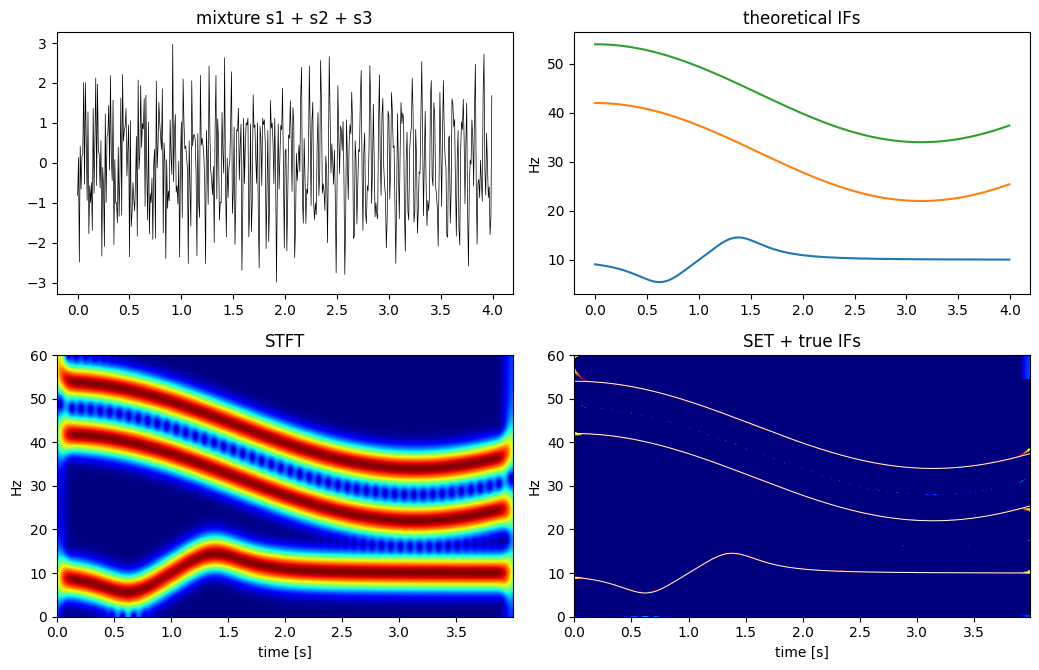

In [2]:
fs = 120.0
t = np.arange(0.0, 4.0, 1.0 / fs)
s1 = np.sin(2.0 * np.pi * (10.0 * t + 2.0 * np.arctan((2.0 * t - 2.0) ** 2)))
s2 = np.sin(2.0 * np.pi * (32.0 * t + 10.0 * np.sin(t)))
s3 = np.sin(2.0 * np.pi * (44.0 * t + 10.0 * np.sin(t)))
mix = s1 + s2 + s3
if1 = 10.0 + 8.0 * (2.0 * t - 2.0) / (1.0 + (2.0 * t - 2.0) ** 4)
if2 = 32.0 + 10.0 * np.cos(t)
if3 = 44.0 + 10.0 * np.cos(t)

engine = SET(hlength=55, fs=fs, n_imfs=3, clear_win=5)
te, freq = engine.transform(mix)
imfs = engine.fit_transform(mix)
print("Te", te.shape, "  IMFs", imfs.shape)
print("relative residual", float(np.linalg.norm(imfs[-1]) / np.linalg.norm(mix)))

fig, axes = plt.subplots(2, 2, figsize=(10.5, 6.8))
axes[0, 0].plot(t, mix, color="k", lw=0.5)
axes[0, 0].set_title("mixture s1 + s2 + s3")
axes[0, 1].plot(t, if1, t, if2, t, if3)
axes[0, 1].set_title("theoretical IFs")
axes[0, 1].set_ylabel("Hz")
axes[1, 0].imshow(
    np.abs(engine.tfr_),
    aspect="auto",
    origin="lower",
    extent=[t[0], t[-1], freq[0], freq[-1]],
    cmap="jet",
)
axes[1, 0].set_title("STFT")
axes[1, 1].imshow(
    np.abs(te),
    aspect="auto",
    origin="lower",
    extent=[t[0], t[-1], freq[0], freq[-1]],
    cmap="jet",
)
axes[1, 1].plot(t, if1, "w-", lw=0.7)
axes[1, 1].plot(t, if2, "w-", lw=0.7)
axes[1, 1].plot(t, if3, "w-", lw=0.7)
axes[1, 1].set_title("SET + true IFs")
for ax in axes[1]:
    ax.set_xlabel("time [s]")
    ax.set_ylabel("Hz")
    ax.set_ylim(0, 60)
fig.tight_layout()

## 3. Modes along SET ridges

`fit_transform` returns four rows: three oscillatory modes plus the
residual. Ridge order follows energy of $|T_e|$, not the original
$s_1,s_2,s_3$ labels, so each recovered mode is matched by correlation.


||x - sum modes|| / ||x|| = 0.0849


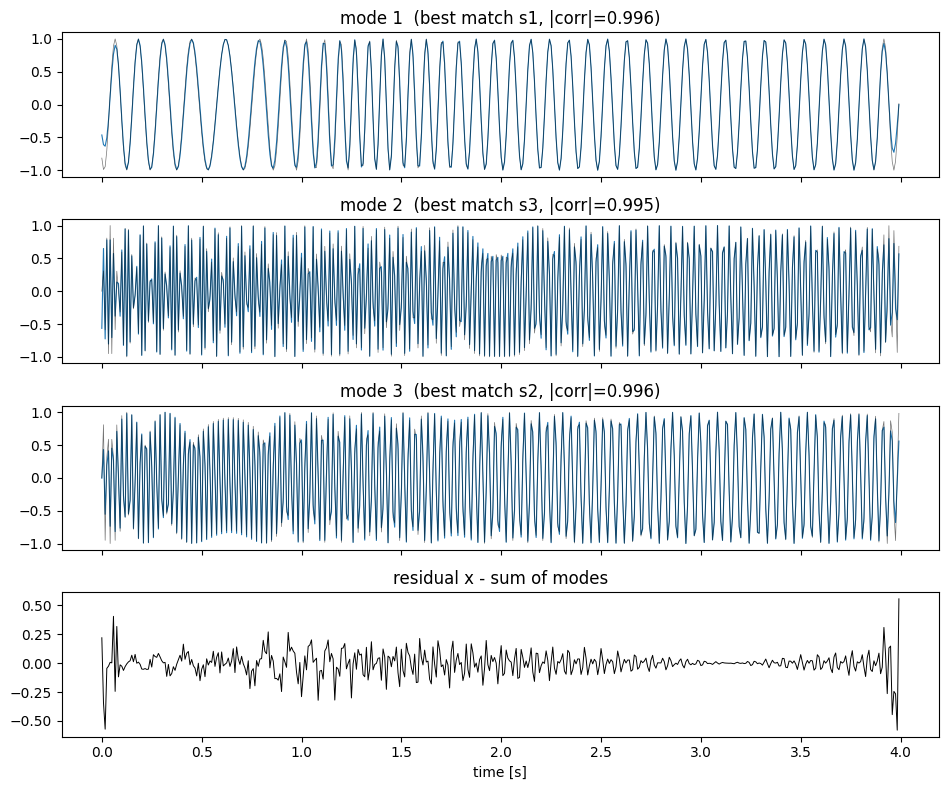

In [3]:
sources = {"s1": s1, "s2": s2, "s3": s3}
fig, axes = plt.subplots(4, 1, figsize=(9.5, 8.0), sharex=True)
for k, ax in enumerate(axes[:3]):
    ax.plot(t, imfs[k], color="C0", lw=0.8)
    best = max(sources, key=lambda name: abs(np.corrcoef(imfs[k], sources[name])[0, 1]))
    corr = abs(np.corrcoef(imfs[k], sources[best])[0, 1])
    ax.plot(t, sources[best], color="k", lw=0.5, alpha=0.55)
    ax.set_title("mode {}  (best match {}, |corr|={:.3f})".format(k + 1, best, corr))
axes[3].plot(t, imfs[-1], color="k", lw=0.7)
axes[3].set_title("residual x - sum of modes")
axes[3].set_xlabel("time [s]")
fig.tight_layout()

recon = np.sum(imfs[:3], axis=0)
print(
    "||x - sum modes|| / ||x|| = {:.4f}".format(
        np.linalg.norm(mix - recon) / np.linalg.norm(mix)
    )
)

## 4. Instantaneous-frequency trajectories

The integer ridge `SET.ridges_` indexes frequency bins of $T_e$.
Converted by $f=k\,F_s/N$ they should overlay the three theoretical IFs.


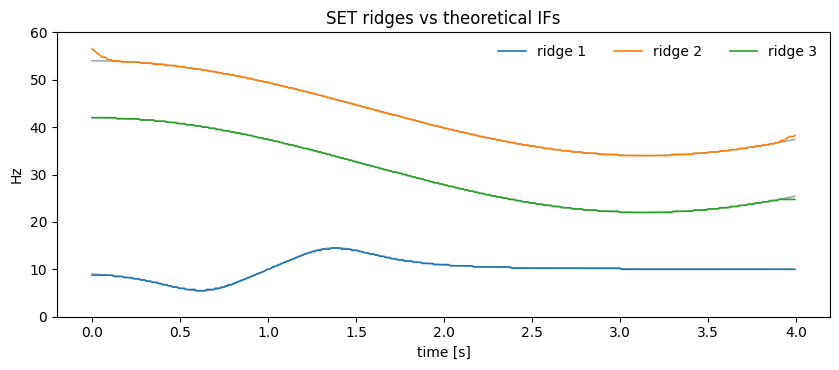

In [4]:
ridges = engine.ridges_
fig, ax = plt.subplots(figsize=(8.5, 3.8))
ax.plot(t, if1, "k-", lw=1.0, alpha=0.4)
ax.plot(t, if2, "k-", lw=1.0, alpha=0.4)
ax.plot(t, if3, "k-", lw=1.0, alpha=0.4)
for k in range(ridges.shape[0]):
    ax.plot(t, freq[ridges[k]], lw=1.2, label="ridge {}".format(k + 1))
ax.set_ylim(0, 60)
ax.set_xlabel("time [s]")
ax.set_ylabel("Hz")
ax.set_title("SET ridges vs theoretical IFs")
ax.legend(frameon=False, ncol=3)
fig.tight_layout()